In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
def leer_csv(ruta_archivo):
    """
    Función para leer un archivo CSV con cabecera. Los datos están separados por comas y están todos (valores y texto) entre comillas " "

    """
    try:
        df = pd.read_csv(
            ruta_archivo,
            sep=',',          # Indicamos que el separador es la coma
            header=0,         # Indicamos que la fila 0 (la primera) tiene las etiquetas
            quotechar='"'     # Le decimos que ignore las comas que estén dentro de las comillas
        )
        print("¡Archivo CSV cargado con éxito!")
        return df
        
    except FileNotFoundError:
        print(f"Error: No se ha encontrado el archivo en la ruta '{ruta_archivo}'.")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado al leer el CSV: {e}")
        return None



In [ ]:
colores = {
   0: '#C72A66',     
   1: '#B16A3C',      
   2: '#1E8675',   
   3: "#7D1485"  
}


Primera gráfica: RMSE de los datos de validación para el conjunto de día

In [ ]:
rmse_val_day=leer_csv('rmse_valheight_day.csv')


etiquetas_day = rmse_val_day.columns.tolist()
print("Las etiquetas del archivo rmse_valheight_day.csv son:")
for etiqueta in etiquetas_day:
    print(f" -> '{etiqueta}'")

epocas_day=rmse_val_day['Step']
epocas_day=round(epocas_day/(epocas_day.iloc[-1]/100))


¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_valheight_day.csv son:
 -> 'Step'
 -> 'test-model_082337 - Val RMSE Validación (metros)'
 -> 'test-model_082337 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_082337 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_080952 - Val RMSE Validación (metros)'
 -> 'test-model_080952 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_080952 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_060949 - Val RMSE Validación (metros)'
 -> 'test-model_060949 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_060949 - Val RMSE Validación (metros)__MAX'
 -> 'test-model_051324 - Val RMSE Validación (metros)'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MIN'
 -> 'test-model_051324 - Val RMSE Validación (metros)__MAX'


<function matplotlib.pyplot.show(close=None, block=None)>

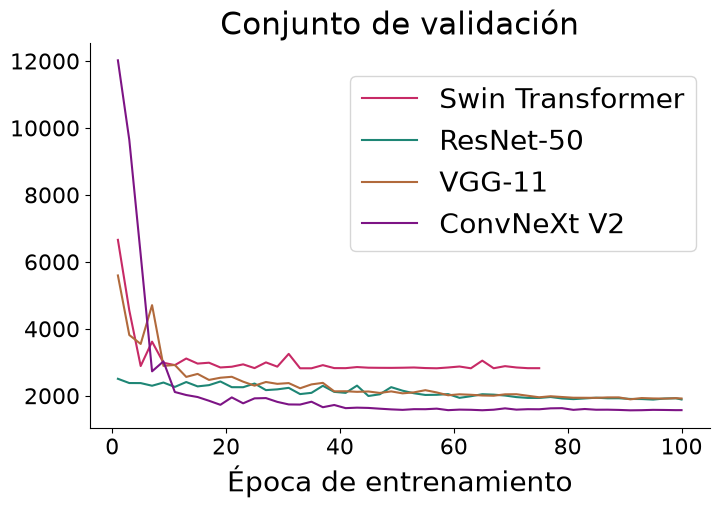

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epocas_day, rmse_val_day['test-model_082337 - Val RMSE Validación (metros)'], label='Swin Transformer', color=colores[0])
plt.plot(epocas_day, rmse_val_day['test-model_060949 - Val RMSE Validación (metros)'], label='ResNet-50', color=colores[2])
plt.plot(epocas_day, rmse_val_day['test-model_080952 - Val RMSE Validación (metros)'], label='VGG-11', color=colores[1])
plt.plot(epocas_day, rmse_val_day['test-model_051324 - Val RMSE Validación (metros)'], label='ConvNeXt V2', color=colores[3])
plt.xlabel('Época de entrenamiento', fontsize=20)
plt.ylabel('RMSE / m', fontsize=20)
plt.title('Conjunto de validación', fontsize=22)
plt.legend(fontsize=20,  bbox_to_anchor=(1.0, 0.95))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show

In [58]:
rmse_train_day=leer_csv('rmse_trainheight_day.csv')

etiquetas2_day = rmse_train_day.columns.tolist()
print("Las etiquetas del archivo rmse_trainheight_day.csv son:")
for etiqueta in etiquetas2_day:
    print(f" -> '{etiqueta}'")

epocas2_day=rmse_train_day['Step']
epocas2_day=epocas2_day/(epocas2_day.iloc[-1]/100)


¡Archivo CSV cargado con éxito!
Las etiquetas del archivo rmse_trainheight_day.csv son:
 -> 'Step'
 -> 'test-model_082337 - Train RMSE (meters)'
 -> 'test-model_082337 - Train RMSE (meters)__MIN'
 -> 'test-model_082337 - Train RMSE (meters)__MAX'
 -> 'test-model_080952 - Train RMSE (meters)'
 -> 'test-model_080952 - Train RMSE (meters)__MIN'
 -> 'test-model_080952 - Train RMSE (meters)__MAX'
 -> 'test-model_060949 - Train RMSE (meters)'
 -> 'test-model_060949 - Train RMSE (meters)__MIN'
 -> 'test-model_060949 - Train RMSE (meters)__MAX'
 -> 'test-model_051324 - Train RMSE (meters)'
 -> 'test-model_051324 - Train RMSE (meters)__MIN'
 -> 'test-model_051324 - Train RMSE (meters)__MAX'


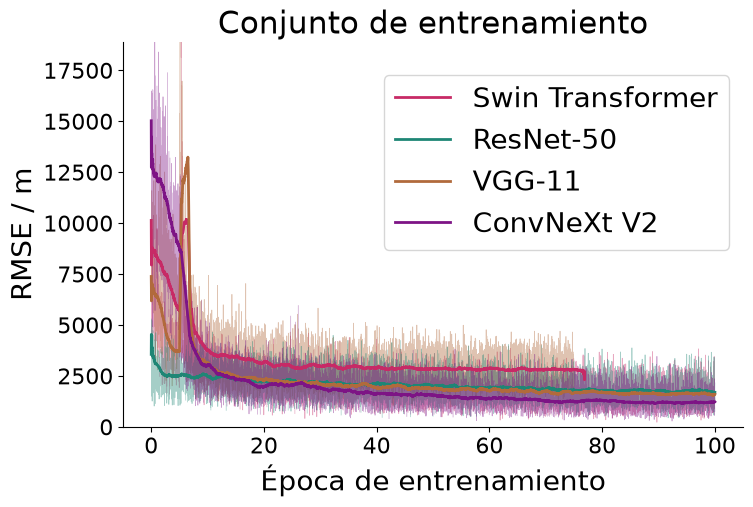

In [69]:
plt.figure(figsize=(8,5))

everyN=1
window=200

train_convnext = rmse_train_day['test-model_051324 - Train RMSE (meters)'][::everyN]
train_resnet = rmse_train_day['test-model_060949 - Train RMSE (meters)'][::everyN]
train_vgg = rmse_train_day['test-model_080952 - Train RMSE (meters)'][::everyN]
train_swin = rmse_train_day['test-model_082337 - Train RMSE (meters)'][::everyN]

convnext_avg = train_convnext.rolling(window=window, min_periods=1).mean()
resnet_avg = train_resnet.rolling(window=window, min_periods=1).mean()
vgg_avg = train_vgg.rolling(window=window, min_periods=1).mean()
swin_avg = train_swin.rolling(window=window, min_periods=1).mean()

y_max=np.amax(train_convnext)


plt.plot(epocas2_day[::everyN], train_vgg, color=colores[0], linewidth=0.5, alpha=0.4)
plt.plot(epocas2_day[::everyN], train_swin, color=colores[1], linewidth=0.5, alpha=0.4)
plt.plot(epocas2_day[::everyN], train_resnet, color=colores[2], linewidth=0.5, alpha=0.4)
plt.plot(epocas2_day[::everyN], train_convnext, color=colores[3], linewidth=0.5, alpha=0.4)


plt.plot(epocas2_day[::everyN], swin_avg, label='Swin Transformer', color=colores[0], linewidth=2)
plt.plot(epocas2_day[::everyN], resnet_avg, label='ResNet-50', color=colores[2], linewidth=2)
plt.plot(epocas2_day[::everyN], vgg_avg, label='VGG-11', color=colores[1], linewidth=2)

plt.plot(epocas2_day[::everyN], convnext_avg, label='ConvNeXt V2', color=colores[3], linewidth=2)

plt.xlabel('Época de entrenamiento', fontsize=20)
plt.ylabel('RMSE / m', fontsize=20)
plt.title('Conjunto de entrenamiento', fontsize=22)
plt.legend(fontsize=20, bbox_to_anchor=(1.0, 0.95))
plt.ylim(0, y_max)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()